# **VGG16 for Plant Disease Detection**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set your data and model paths
data_dir = '/content/drive/MyDrive/disease/Plant_images'
model_path = '/content/vgg16_model.h5'

# Set parameters
batch_size = 32
image_size = (224, 224)  # VGG16 input size
epochs = 5

In [ ]:
# Data preprocessing
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 4398 images belonging to 11 classes.
Found 1099 images belonging to 11 classes.


In [ ]:
# Create the VGG16 model
base_model = VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator)

Epoch 1/5
138/138 [==============================] - 40s 234ms/step - loss: 1.0204 - accuracy: 0.7051 - val_loss: 0.1573 - val_accuracy: 0.9663
Epoch 2/5
138/138 [==============================] - 22s 156ms/step - loss: 0.2801 - accuracy: 0.9075 - val_loss: 0.0799 - val_accuracy: 0.9782
Epoch 3/5
138/138 [==============================] - 22s 156ms/step - loss: 0.1948 - accuracy: 0.9368 - val_loss: 0.0912 - val_accuracy: 0.9763
Epoch 4/5
138/138 [==============================] - 22s 162ms/step - loss: 0.1374 - accuracy: 0.9554 - val_loss: 0.0552 - val_accuracy: 0.9818
Epoch 5/5
138/138 [==============================] - 24s 170ms/step - loss: 0.1309 - accuracy: 0.9552 - val_loss: 0.0606 - val_accuracy: 0.9791


In [ ]:
# Save the model
model.save(model_path)

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_generator)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')

35/35 [==============================] - 4s 122ms/step - loss: 0.0606 - accuracy: 0.9791
Validation Accuracy: 97.91%


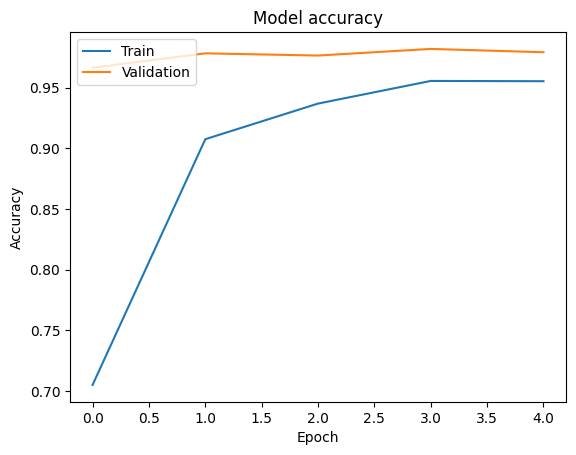

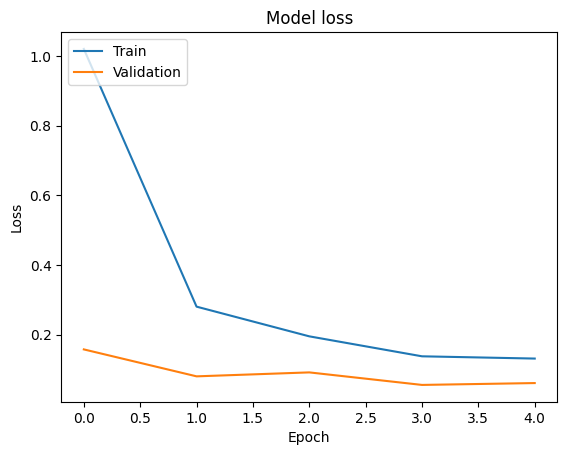

In [ ]:
# Visualize training history
def plot_training_history(history):
    # Plot training & validation accuracy values
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

    # Plot training & validation loss values
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_training_history(history)

35/35 [==============================] - 4s 120ms/step


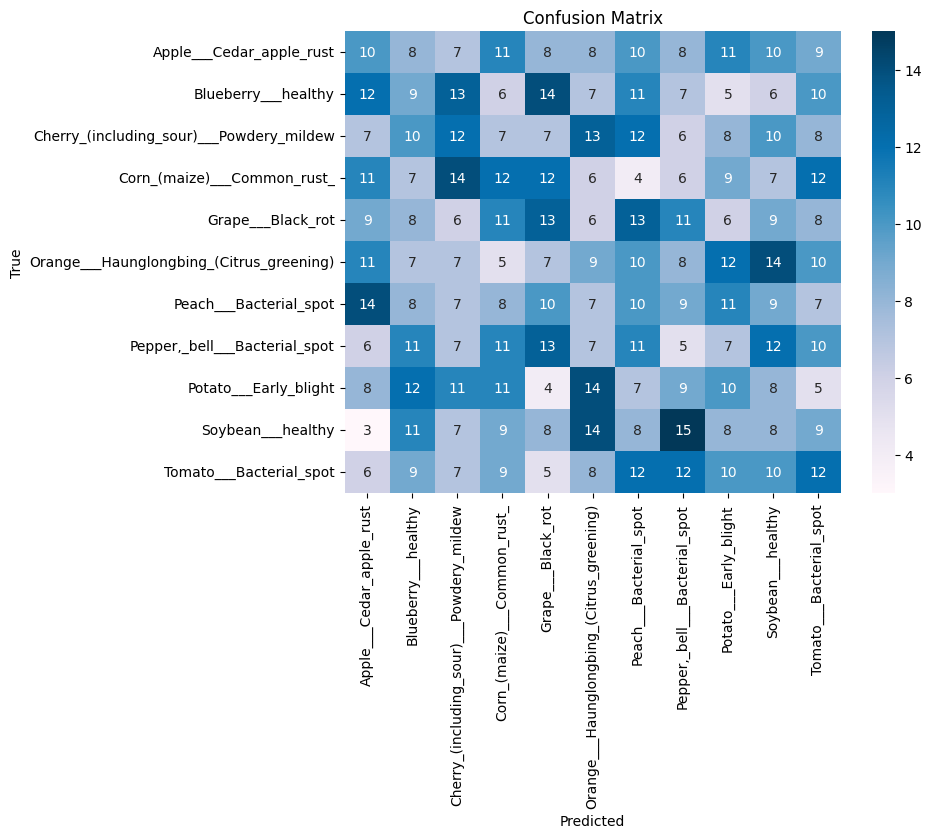

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# Generate predictions
y_true = validation_generator.classes
y_pred = np.argmax(model.predict(validation_generator), axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='PuBu', xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# Classification report
class_labels = list(train_generator.class_indices.keys())
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))


Classification Report:
                                           precision    recall  f1-score   support

                Apple___Cedar_apple_rust       0.10      0.10      0.10       100
                     Blueberry___healthy       0.09      0.09      0.09       100
Cherry_(including_sour)___Powdery_mildew       0.12      0.12      0.12       100
             Corn_(maize)___Common_rust_       0.12      0.12      0.12       100
                       Grape___Black_rot       0.13      0.13      0.13       100
Orange___Haunglongbing_(Citrus_greening)       0.09      0.09      0.09       100
                  Peach___Bacterial_spot       0.09      0.10      0.10       100
           Pepper,_bell___Bacterial_spot       0.05      0.05      0.05       100
                   Potato___Early_blight       0.10      0.10      0.10        99
                       Soybean___healthy       0.08      0.08      0.08       100
                 Tomato___Bacterial_spot       0.12      0.12      0.12 